# Advanced Scientific Computing and Machine Learning Guide

This notebook covers fundamental tools for advanced scientific data processing, curve fitting, optimization, data manipulation, and foundational classification models in Python using SciPy, Pandas, and Scikit-Learn.

## 1. SciPy: Numerical Integration & Optimization

SciPy provides core algorithms for scientific computing, including numerical integration, optimization, statistics, and signal processing.

<img src="https://imgs.xkcd.com/comics/curve_fitting.png" width="400">

### Function to Integrate

We define a function to integrate and then calculate the definite integral using the `quad()`.

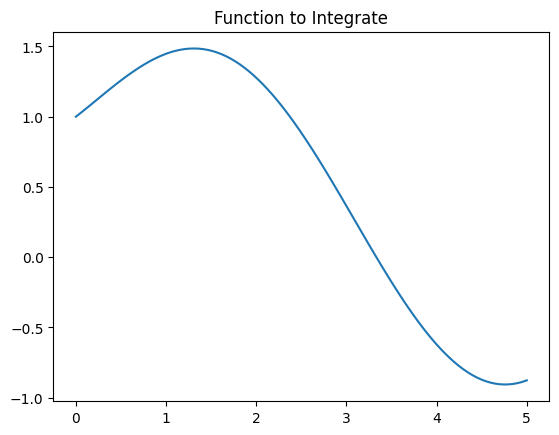

Integral result: 2.552167817288976 (Estimated error: 5.1728440031774725e-14)


In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, simpson, trapezoid
from scipy.optimize import curve_fit
from scipy.interpolate import CubicSpline

# Define a test function for numerical integration: f(x) = sin(x) + exp(-x/2)
def integrand(x):
    return np.sin(x) + np.exp(-x/2)

# Plot the function
xs = np.linspace(0, 5, 100)
fig, ax = plt.subplots()
ax.plot(xs, integrand(xs))
plt.title("Function to Integrate")
plt.show()

# Compute the definite integral from 0 to 5
result, error = quad(integrand, 0, 5)
print(f"Integral result: {result} (Estimated error: {error})")

### Integration from Samples

If we have functions defined by discrete samples rather than analytical formulas, we can use numerical methods like the trapezoidal rule or Simpson's rule.

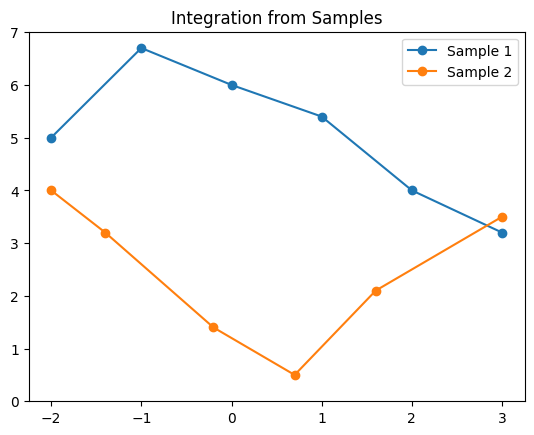

I1 (trapezoid): 26.2
I1 (Simpson):   26.683333333333334

I2 (trapezoid): 10.864999999999998
I2 (Simpson):   10.674653784219


In [65]:
# Sample data
x1 = np.linspace(-2., 3., 6)
f1 = np.array([5., 6.7, 6, 5.4, 4., 3.2])

x2 = np.array([-2., -1.4, -0.2, 0.7, 1.6, 3.])
f2 = np.array([4., 3.2, 1.4, 0.5, 2.1, 3.5])

# Plot the samples
fig, ax = plt.subplots()
plt.plot(x1, f1, marker='o', label='Sample 1')
plt.plot(x2, f2, marker='o', label='Sample 2')
plt.ylim(bottom=0)
plt.legend()
plt.title("Integration from Samples")
plt.show()

# Calculate integrals
print('I1 (trapezoid):', trapezoid(f1, x=x1))
print('I1 (Simpson):  ', simpson(f1, x=x1))
print('\nI2 (trapezoid):', trapezoid(f2, x=x2))
print('I2 (Simpson):  ', simpson(f2, x=x2))

### Interpolation

SciPy also provides a variety of classes for interpolation, such as `CubicSpline`, which performs cubic interpolation (continuous up to the second derivative).

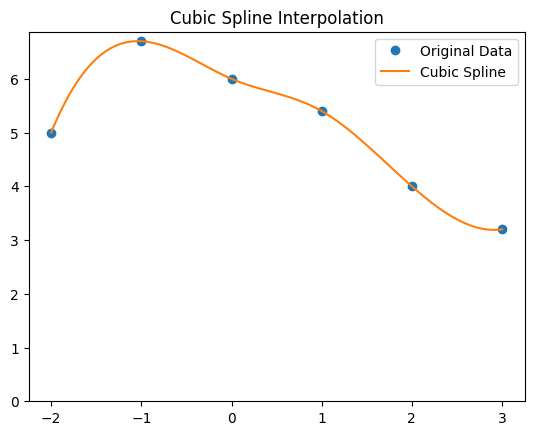

Interpolated value at x=1.5: 4.765000000000001


In [66]:
# Fit the cubic spline
spline = CubicSpline(x1, f1)

# Plotting the spline
fig, ax = plt.subplots()
x_fine = np.linspace(-2, 3, 100)
plt.plot(x1, f1, ls='', marker='o', label='Original Data')
plt.plot(x_fine, spline(x_fine), label='Cubic Spline')
plt.ylim(bottom=0)
plt.legend()
plt.title("Cubic Spline Interpolation")
plt.show()

# Interpolated value at x=1.5
print(f"Interpolated value at x=1.5: {spline(1.5)}")

### Chi-Square and Normal Distribution Analysis

Visualizing probability density functions (PDF) for Chi-Square and Normal distributions using `scipy.stats`. This includes calculating cumulative distribution functions (CDF), p-values, and shading the areas under the curve for specific regions.

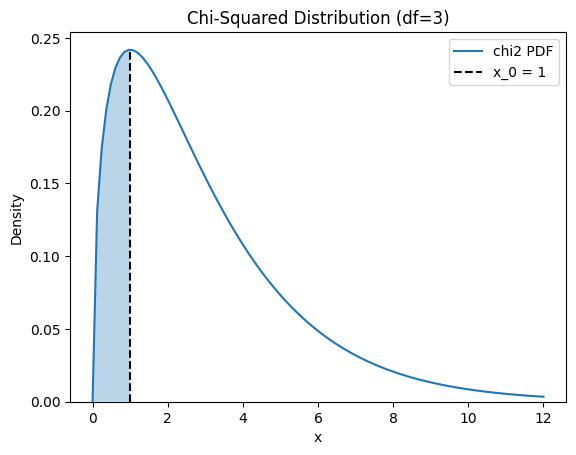

P(x < 6) = 0.8883897749052875
p-value (x > 6): 0.11161022509471252


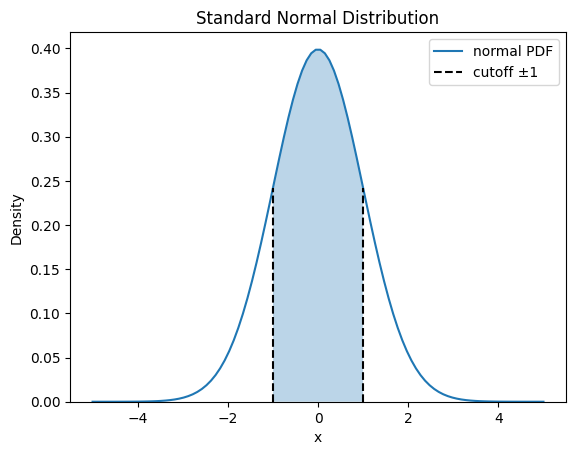

2-tailed p-value (x < -1 | x > 1): 0.31731050786291415
Area under the curve: 0.6826894921370859


In [67]:
from scipy.stats import chi2, norm

# Plot the chi-squared distribution with 3 degrees of freedom
x_pos = np.linspace(0, 12, 100)
fig, ax = plt.subplots()
ax.plot(x_pos, chi2.pdf(x_pos, 3), label='chi2 PDF')
ax.set_ylim(bottom=0)
ax.set_title('Chi-Squared Distribution (df=3)')
ax.set_xlabel('x')
ax.set_ylabel('Density')

# Visualize the area under the curve for x <= x_0
x_draw = np.append(x_pos[x_pos <= x_0], x_0)
ax.vlines(x=x_0, ymin=0, ymax=chi2.pdf(x_0, 3), ls='--', color='k', label=f'x_0 = {x_0}')
ax.fill_between(x=x_draw, y1=0, y2=chi2.pdf(x_draw, 3), alpha=.3)
ax.legend()
plt.show()

# Calculate the cumulative distribution function (CDF) at x_0
x_0 = 6
cdf = chi2.cdf(x_0, 3)
print(f'P(x < {x_0}) = {cdf}')

# Calculate the p-value for x > x_0
p_val = 1 - cdf
print(f'p-value (x > {x_0}): {p_val}')

# Calculate the quantile (inverse CDF) for a given probability
chi2.ppf(cdf, 3)

# Plot the standard normal distribution
x_0 = 1
x = np.linspace(-5, 5, 100)
fig, ax = plt.subplots()
ax.plot(x, norm.pdf(x), label='normal PDF')
ax.set_title('Standard Normal Distribution')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.set_ylim(bottom=0)

# Visualize the area under the curve for x < -x_0 and x > x_0
x_draw = np.concatenate(([-x_0], x[(x > -x_0) & (x < x_0)], [x_0]))
ax.vlines(x=[-x_0, x_0], ymin=0, ymax=norm.pdf(x_0), ls='--', color='k', label=f'cutoff ±{x_0}')
ax.fill_between(x=x_draw, y1=0, y2=norm.pdf(x_draw), alpha=.3)
ax.legend()
plt.show()

# Calculate the 2-tailed p-value for x < -x_0 and x > x_0
p_val_2tail = 2*(1 - norm.cdf(x_0))
print(f'2-tailed p-value (x < {-x_0} | x > {x_0}): {p_val_2tail}')
print(f'Area under the curve: {1-p_val_2tail}')

### Gaussian Distribution Fitting

Generating a random sample from a Gaussian distribution and plotting its histogram. Then, we use SciPy to fit a normal distribution to the data to recover the original parameters (mean and variance).

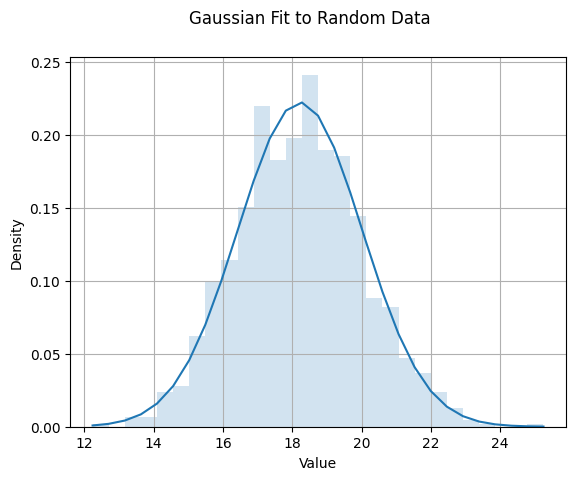

Real values: 18.182496720710063 1.8340450985343382
Values obtained from fit: 18.223155042480784 1.7959491308484858


In [68]:
# Randomly generate data from a Gaussian distribution, with mean between 0 and 100 and variance between 0 and 10
from numpy.linalg import norm
from scipy.stats import norm

# Generate random mean and variance
mean = np.random.rand()*100
var = np.random.rand()*10
mean = np.random.rand() * 100
var = np.random.rand() * 10
data = norm.rvs(size=1000, loc=mean, scale=var)

# Plot the histogram of the data and the fitted Gaussian distribution
fig, ax = plt.subplots()
h = ax.hist(data, density=True, bins='auto', histtype='stepfilled', alpha=0.2)
# The hist() method returns a tuple where the first element is an array with histogram values and the second is an array with bin edges
bins = h[1]

# Fit the distribution to the data
loc, scale = norm.fit(data)

# Plot the fitted Gaussian distribution
ax.plot(bins, norm.pdf(bins, loc=loc, scale=scale), color='C0')
fig.suptitle("Gaussian Fit to Random Data")
plt.xlabel("Value")
plt.ylabel("Density")
plt.grid(True)
plt.show()

# Values obtained from fit should be close to the real values used to generate the data
print('Real values:', mean, var)
print('Values obtained from fit:', loc, scale)

### Experimental Curve Fitting

Using `curve_fit` to extract physical parameters from noisy experimental data by fitting a target theoretical model function.

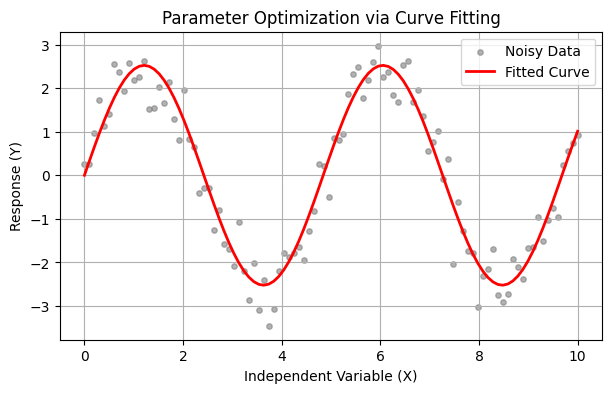

Optimized parameters -> a: 2.523, b: 1.298


In [69]:
# Define the theoretical model function: f(x) = a * sin(b * x)
def model_func(x, a, b):
    return a * np.sin(b * x)

# Generate noisy experimental data
np.random.seed(42)
x_data = np.linspace(0, 10, 100)
y_clean = 2.5 * np.sin(1.3 * x_data)
noise = np.random.normal(0, 0.5, len(x_data))
y_data = y_clean + noise

# Fit the model function to the experimental data
popt, pcov = curve_fit(model_func, x_data, y_data, p0=[2, 1])

# Plot the results
plt.figure(figsize=(7, 4))
plt.scatter(x_data, y_data, label='Noisy Data', color='gray', alpha=0.6, s=15)
plt.plot(x_data, model_func(x_data, *popt), label='Fitted Curve', color='red', linewidth=2)
plt.legend()
plt.title("Parameter Optimization via Curve Fitting")
plt.xlabel("Independent Variable (X)")
plt.ylabel("Response (Y)")
plt.grid(True)
plt.show()

# Print the optimized parameters
print(f"Optimized parameters -> a: {popt[0]:.3f}, b: {popt[1]:.3f}")

### Advanced Curve Fitting with Error Bounds

Fitting a power-law model to data with Poisson errors. We calculate expected values, add noise to generate synthetic experimental data, and use `scipy.optimize.curve_fit` to estimate the model parameters alongside their uncertainties.

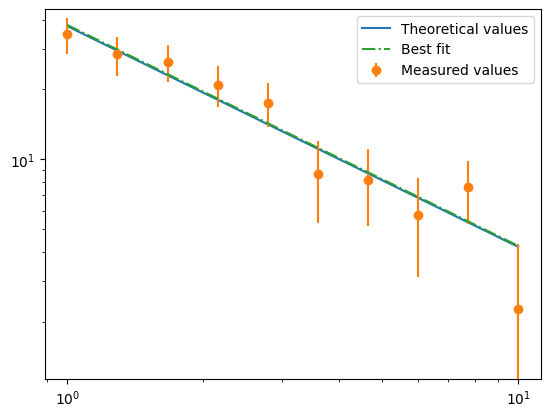

Real values:
a : 37.4540
b : 0.9507

Values obtained from fit:
a : 37.9009 +/- 4.3537
b : 0.9514 +/- 0.1228


In [70]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as optimize

# Generate random data
np.random.seed(42)
amp = np.random.rand()*100
index = np.random.rand()
x = np.geomspace(1, 10, 10)

# Calculate expected values and Poisson errors (square root of expected values)
expected_values = amp*x**-index
errors = np.sqrt(expected_values)

# Generate "data" by adding noise to expected values
noise = [(1 - np.random.rand()*2)*err for err in errors]
data = expected_values + noise

# Define a function that returns the model output
def fit_function(x, a, b):
    return a*x**-b

# Define initial parameter values
p0 = [50, 0.5]

# Apply the least squares method
popt, pcov = optimize.curve_fit(fit_function, x, data, p0=p0, sigma=errors, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))

# Plotting the results
fig, ax = plt.subplots()
ax.set_xscale('log')
ax.set_yscale('log')
ax.plot(x, expected_values, label='Theoretical values')
ax.errorbar(x, data, yerr=errors, label='Measured values', ls='', marker='o')
ax.plot(x, fit_function(x, popt[0], popt[1]), label='Best fit', ls='-.')
ax.set_ylim(bottom=min(data)*0.5)
ax.legend()
plt.show()

# Print the real values and the values obtained from the fit
print('Real values:')
print(f'a : {amp:.4f}')
print(f'b : {index:.4f}')

print('\nValues obtained from fit:')
print(f'a : {popt[0]:.4f} +/- {perr[0]:.4f}')
print(f'b : {popt[1]:.4f} +/- {perr[1]:.4f}')

## 2. Pandas: Data Manipulation

<img src="https://imgs.xkcd.com/comics/data_trap.png" width="400">

Pandas is optimized for handling large datasets. Its core classes are `Series` and `DataFrame`.
Let's explore some basics of DataFrame manipulation.

In [71]:
import pandas as pd

# Creating a sample DataFrame (similar to a loaded CSV)
data = {
    'order_id': [1001, 1002, 1003, 1004, 1005, 1006],
    'date': ['2024-01-05', '2024-01-07', '2024-01-08', '2024-01-10', '2024-01-12', '2024-01-15'],
    'customer': ['Alice', 'Bob', 'Charlie', 'Diana', 'Edward', 'Fiona'],
    'region': ['North', 'South', 'East', 'West', 'North', 'South'],
    'product': ['Laptop', 'Headphones', 'Desk', 'Chair', 'Monitor', 'Mouse'],
    'category': ['Electronics', 'Electronics', 'Furniture', 'Furniture', 'Electronics', 'Electronics'],
    'quantity': [1, 2, 1, 4, 2, 3],
    'price': [1200.0, 150.0, 300.0, 85.0, 220.0, 25.0],
    'discount': [0.10, 0.05, 0.00, 0.15, 0.10, 0.00],
    'rating': [4.5, 4.2, 4.0, 3.8, 4.3, 4.1]
}
df = pd.DataFrame(data)

# Display the first few rows
display(df.head())

# Accessing a specific set of rows and columns
display(df.loc[[2, 5, 3], ['price', 'date']])

# Filtering data: select items with price > 200
display(df[df['price'] > 200])

,order_id,date,customer,region,product,category,quantity,price,discount,rating
0,1001,2024-01-05,Alice,North,Laptop,Electronics,1,1200.0,0.10,4.5
1,1002,2024-01-07,Bob,South,Headphones,Electronics,2,150.0,0.05,4.2
2,1003,2024-01-08,Charlie,East,Desk,Furniture,1,300.0,0.00,4.0
3,1004,2024-01-10,Diana,West,Chair,Furniture,4,85.0,0.15,3.8
4,1005,2024-01-12,Edward,North,Monitor,Electronics,2,220.0,0.10,4.3


,price,date
2,300.0,2024-01-08
5,25.0,2024-01-15
3,85.0,2024-01-10


,order_id,date,customer,region,product,category,quantity,price,discount,rating
0,1001,2024-01-05,Alice,North,Laptop,Electronics,1,1200.0,0.1,4.5
2,1003,2024-01-08,Charlie,East,Desk,Furniture,1,300.0,0.0,4.0
4,1005,2024-01-12,Edward,North,Monitor,Electronics,2,220.0,0.1,4.3


## 3. Scikit-Learn: Classification Tasks

Scikit-Learn is the standard library for implementing supervised and unsupervised machine learning algorithms in Python. We will explore tree-based models using the Iris dataset.

In [72]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

### A. Single Decision Tree Classifier

A hierarchical model that partitions data based on feature thresholds to assign objects into predefined, mutually exclusive categories.

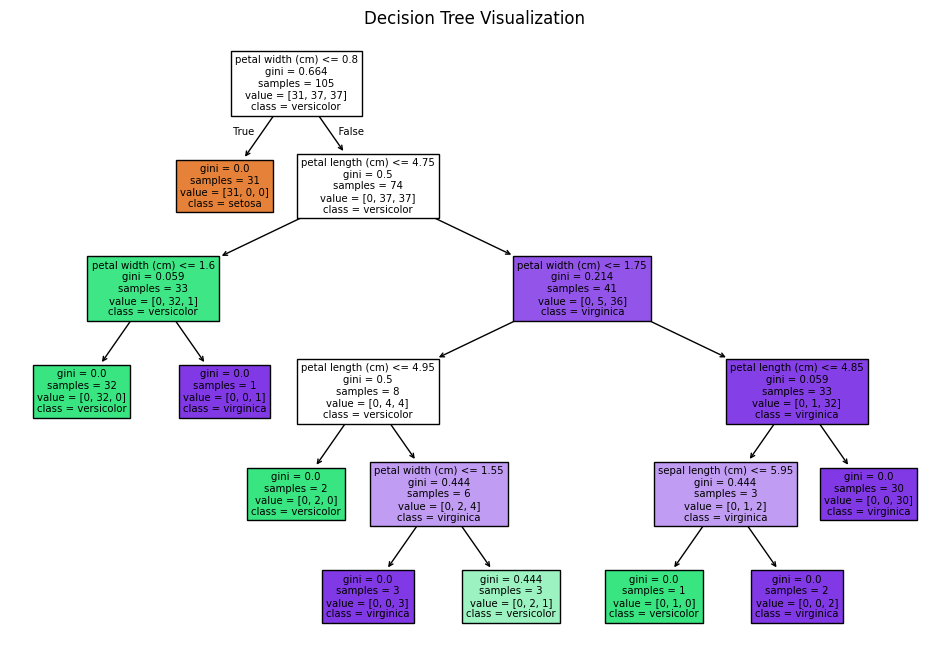

Decision Tree Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [73]:
# Initialize and train the Decision Tree model
tree_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=1)
tree_model.fit(X_train, y_train)

# Visualize the tree
plt.figure(figsize=(12, 8))
plot_tree(tree_model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.title("Decision Tree Visualization")
plt.show()

# Evaluate performance
y_pred_tree = tree_model.predict(X_test)
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_tree, target_names=iris.target_names))

### Cross-Validation for Decision Trees

Evaluating the Decision Tree classifier using K-Fold Cross-Validation (`cross_val_score`). This technique provides a more robust estimate of model accuracy by training and testing on multiple partitions of the data.

In [ ]:
from sklearn.model_selection import cross_val_score

# Perform 10-fold cross-validation on the Decision Tree Classifier
scores = cross_val_score(estimator=dt_classifier,
                         X=X_train,
                         y=y_train,
                         cv=10,
                         scoring='accuracy',
                         n_jobs=-1)

# CV accuracy scores and mean/std
print(f'CV accuracy scores:\n{scores}')
print(f'CV accuracy:\n {np.mean(scores)} +/- {np.std(scores)}')

CV accuracy scores:
[0.90909091 1.         1.         0.72727273 0.81818182 1.
 1.         0.8        1.         0.9       ]
CV accuracy:
 0.9154545454545454 +/- 0.09706860486061791


### Confusion Matrix

Visualizing the performance of our classifier using a Confusion Matrix. This helps us understand not just the overall accuracy, but also the specific types of misclassifications the model makes.

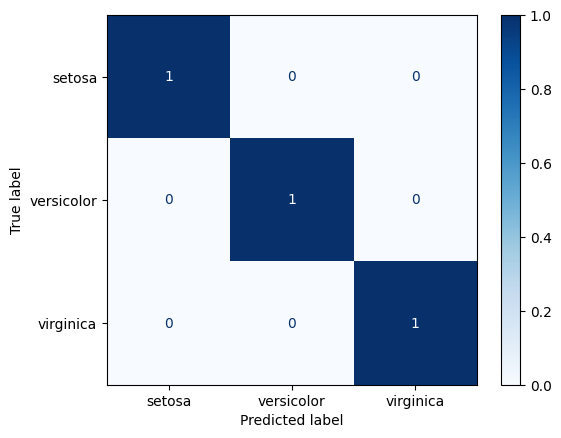

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot the confusion matrix for the Decision Tree Classifier
disp = ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred_tree,
        display_labels=iris['target_names'],
        cmap=plt.cm.Blues,
        normalize='true',
)

### Learning Curve Analysis

Plotting the learning curve to assess how the model's performance improves with varying amounts of training data. This is crucial for diagnosing high bias (underfitting) or high variance (overfitting).

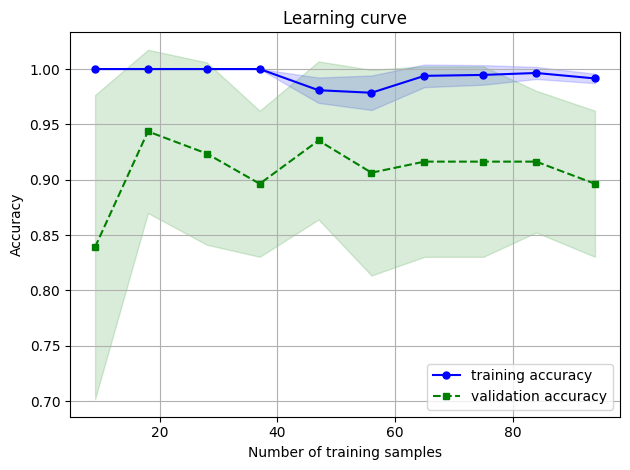

In [81]:
from sklearn.model_selection import learning_curve

# Compute learning curves for the Decision Tree model
train_sizes, train_scores, test_scores = learning_curve(estimator=tree_model,
                               X=X_train,
                               y=y_train,
                               train_sizes=np.linspace(0.1, 1.0, 10),
                               cv=10,
                               n_jobs=-1)

# Plot the learning curves
fig, ax = plt.subplots()

# Calculate mean and standard deviation for training and test scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot the learning curves with shaded areas for standard deviation
plt.plot(train_sizes, train_mean,
         color='blue', marker='o',
         markersize=5, label='training accuracy')

# Shaded area for training accuracy
plt.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

# Plot validation accuracy
plt.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='validation accuracy')

# Shaded area for validation accuracy
plt.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

# Finalize the plot
plt.grid()
plt.xlabel('Number of training samples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Learning curve')
plt.tight_layout()

### Validation Curve Analysis

Plotting a validation curve to observe how model performance changes in response to varying a single hyperparameter (in this case, `max_depth` of the Decision Tree). This helps in finding the optimal hyperparameter value.

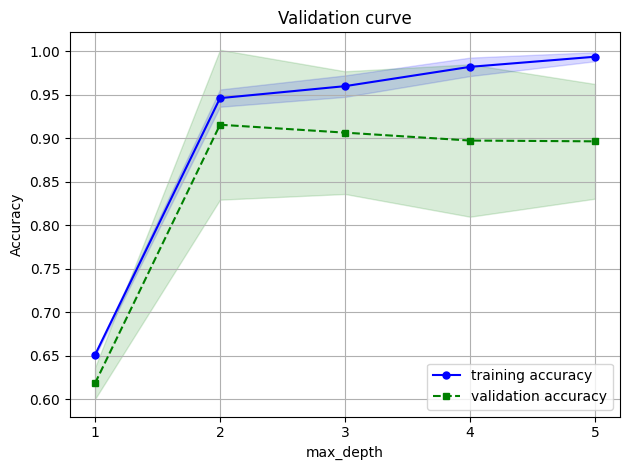

In [82]:
from sklearn.model_selection import validation_curve

# Compute validation curves for the Decision Tree model by varying the max_depth parameter
param_name = 'max_depth'
param_range = np.arange(1, 6)

# Validation curves for the Decision Tree model
train_scores, test_scores = validation_curve(
                estimator=tree_model,
                X=X_train,
                y=y_train,
                param_name=param_name,
                param_range=param_range,
                cv=10)

# Plot the validation curves
fig, ax = plt.subplots()

# Calculate mean and standard deviation for training and test scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot the validation curves with shaded areas for standard deviation
plt.plot(param_range, train_mean,
         color='blue', marker='o',
         markersize=5, label='training accuracy')

# Shaded area for training accuracy
plt.fill_between(param_range, train_mean + train_std,
                 train_mean - train_std, alpha=0.15,
                 color='blue')

# Plot validation accuracy
plt.plot(param_range, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='validation accuracy')

# Shaded area for validation accuracy
plt.fill_between(param_range,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

# Finalize the plot
plt.grid()
plt.legend(loc='lower right')
plt.xlabel(param_name)
plt.ylabel('Accuracy')
plt.xticks(param_range)
# plt.ylim([0.8, 1.03])
plt.title('Validation curve')
plt.tight_layout()

### B. Random Forest Classifier

Notice that in the case of a very simple dataset like Iris, the Random Forest might not bring a massive improvement over a single tree. In general, however, ensemble techniques like Random Forest create algorithms that are more generalizable and less prone to *overfitting* (i.e., excessive dependence on the training data).

In [83]:
# Initialize and train the Random Forest ensemble model
forest_model = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
forest_model.fit(X_train, y_train)

# Evaluate performance
y_pred_forest = forest_model.predict(X_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_forest, target_names=iris.target_names))


Random Forest Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

